<a href="https://colab.research.google.com/github/LUKASZCOM/LICENCJAT/blob/main/ResNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Czyste dane

In [ ]:
## Import bibliotek
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
import matplotlib.pyplot as plt
import time

In [ ]:
## Wgranie zbioru CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)
class_names = ['Samolot', 'Samochód', 'Ptak', 'Kot', 'Jeleń',
               'Pies', 'Żaba', 'Koń', 'Statek', 'Ciężarówka']

## Tworzenie architektury ResNet
def resnet_model():
    input = Input(shape=(32, 32, 3))
    base_model = ResNet50(include_top=False, weights=None, input_tensor=input)
    out = base_model.output

    out1 = GlobalAveragePooling2D()(out)
    out2 = Dense(10, activation='softmax')(out1)

    model = Model(inputs=input, outputs=out2)
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


In [ ]:
## Tworzenie naszego modelu ResNet
model = resnet_model()
model.summary()
start_time = time.time()
resnet_clean = model.fit(
    x_train, y_train_cat,
    epochs=100,
    batch_size=64,
    validation_data=(x_test, y_test_cat),
    verbose=1
)
end_time = time.time()
duration = end_time - start_time
print(f"Czas = {duration}")

In [ ]:
results = model.evaluate(x_test, y_test_cat, verbose=0)
global_loss = results[0]
global_acc = results[1]
print(global_acc)
print(global_loss)

0.7487000226974487
1.5041706562042236


In [ ]:
## Wyciągnięcie parametrów potrzebnych do naszych wykresów (Clean ResNet)
training_accuracy = resnet_clean.history['accuracy']
training_loss = resnet_clean.history['loss']
validation_accuracy = resnet_clean.history['val_accuracy']
validation_loss = resnet_clean.history['val_loss']

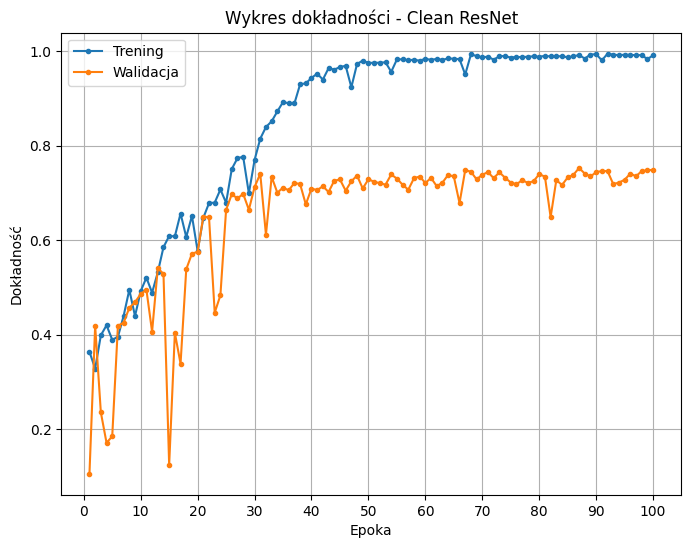

In [ ]:
## Wykres dokładności (Clean ResNet)
epochs_num = range(1, len(training_accuracy) + 1)
plt.figure(figsize=(8, 6))
plt.plot(epochs_num, training_accuracy, label='Trening', marker='.')
plt.plot(epochs_num, validation_accuracy, label='Walidacja', marker='.')

plt.title('Wykres dokładności - Clean ResNet')
plt.xlabel('Epoka')
plt.ylabel('Dokładność')

plt.xticks(range(0, len(training_accuracy) + 1, 10) )
plt.legend()
plt.grid(True)

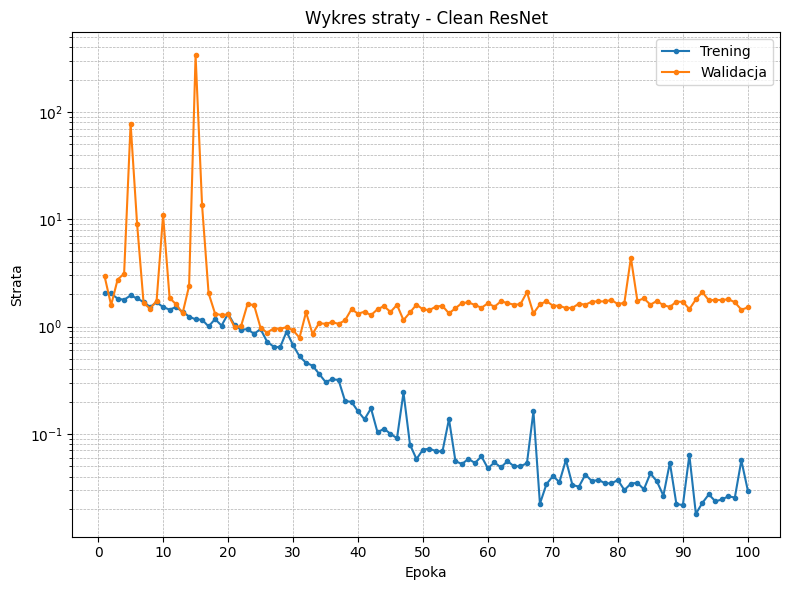

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(epochs_num, training_loss, label='Trening', marker='.')
plt.plot(epochs_num, validation_loss, label='Walidacja', marker='.')

plt.title('Wykres straty - Clean ResNet')
plt.xlabel('Epoka')
plt.ylabel('Strata')

plt.yscale('log')
plt.xticks(range(0, int(max(epochs_num)) + 1, 10))

plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step

--- SZCZEGÓŁOWY RAPORT - Clean Resnet ---
              precision    recall  f1-score   support

     Samolot       0.75      0.82      0.79      1000
    Samochód       0.81      0.86      0.83      1000
        Ptak       0.69      0.66      0.67      1000
         Kot       0.57      0.58      0.58      1000
       Jeleń       0.72      0.74      0.73      1000
        Pies       0.67      0.62      0.64      1000
        Żaba       0.87      0.74      0.80      1000
         Koń       0.77      0.82      0.80      1000
      Statek       0.84      0.82      0.83      1000
  Ciężarówka       0.80      0.83      0.81      1000

    accuracy                           0.75     10000
   macro avg       0.75      0.75      0.75     10000
weighted avg       0.75      0.75      0.75     10000



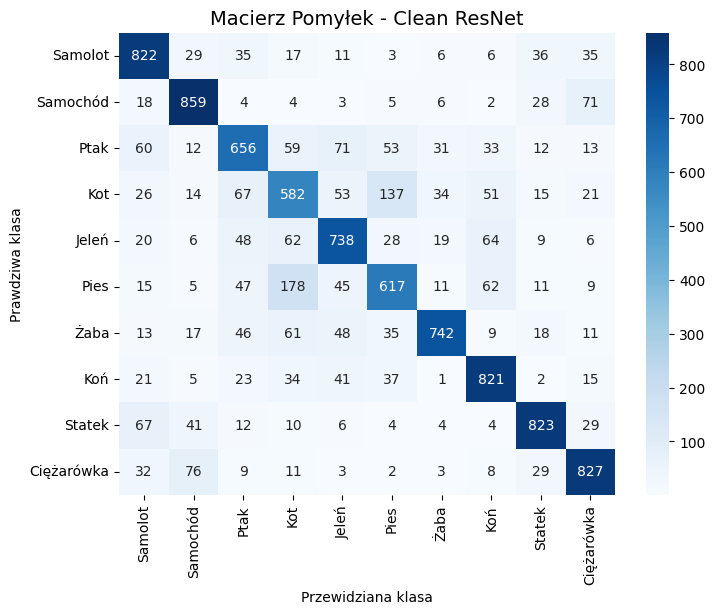

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

print("\n--- SZCZEGÓŁOWY RAPORT - Clean Resnet ---")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Macierz Pomyłek - Clean ResNet')
plt.ylabel('Prawdziwa klasa')
plt.xlabel('Przewidziana klasa')
plt.show()

# Label Flipping

In [ ]:
def poison_label(y_train_cat, ratio):
    y_pois_label = np.copy(y_train_cat)
    labels = np.argmax(y_train_cat, axis=1)

    for a, b in [(1,9), (3,5)]:
        for c, d in [(a,b), (b,a)]:
            indx = np.where(labels == c)[0]
            wybor = np.random.choice(indx, int(len(indx) * ratio), replace=False)
            y_pois_label[wybor, :] = 0
            y_pois_label[wybor, d] = 1
    return y_pois_label

## 10%

In [ ]:
## Tworzenie naszego modelu ResNet
import numpy as np
y_train_poisoned_10 = poison_label(y_train_cat, ratio=0.1)
model = resnet_model()
model.summary()
start_time = time.time()
resnet_10 = model.fit(
    x_train, y_train_poisoned_10,
    epochs=100,
    batch_size=64,
    validation_data=(x_test, y_test_cat),
    verbose=1
)
end_time = time.time()
duration = end_time - start_time
print(f"Czas = {duration}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 38, 38, 3) │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 16, 16,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 16, 16,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 16, 16,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 18, 18,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 8, 8, 64)  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 8, 64)  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 8, 64)  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 8, 8, 256) │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_3_c

 Total params: 23,608,202 (90.06 MB)

 Trainable params: 23,555,082 (89.86 MB)

 Non-trainable params: 53,120 (207.50 KB)

Epoch 1/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 129s 81ms/step - accuracy: 0.3249 - loss: 2.0957 - val_accuracy: 0.2542 - val_loss: 18.8036
Epoch 2/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 39ms/step - accuracy: 0.3748 - loss: 1.9150 - val_accuracy: 0.1033 - val_loss: 1074.9689
Epoch 3/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.4289 - loss: 1.7355 - val_accuracy: 0.1830 - val_loss: 3.1509
Epoch 4/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 39ms/step - accuracy: 0.3968 - loss: 1.8388 - val_accuracy: 0.2279 - val_loss: 3.5117
Epoch 5/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.4393 - loss: 1.6509 - val_accuracy: 0.4894 - val_loss: 1.4121
Epoch 6/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.4705 - loss: 1.5892 - val_accuracy: 0.3490 - val_loss: 1.8588
Epoch 7/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.4754 - loss: 1.5747 - val_accuracy: 0.2949 - val_loss: 5.3457
Epoch 8/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 41ms/step - accuracy: 0.4768 - lo

In [ ]:
results_10 = model.evaluate(x_test, y_test_cat, verbose=0)
global_loss_10 = results_10[0]
global_acc_10 = results_10[1]
print(global_acc_10)
print(global_loss_10)

0.7229999899864197
1.9745665788650513


In [ ]:
## Wyciągnięcie parametrów potrzebnych do naszych wykresów (ResNet 10%)
training_accuracy_10 = resnet_10.history['accuracy']
training_loss_10 = resnet_10.history['loss']
validation_accuracy_10 = resnet_10.history['val_accuracy']
validation_loss_10 = resnet_10.history['val_loss']

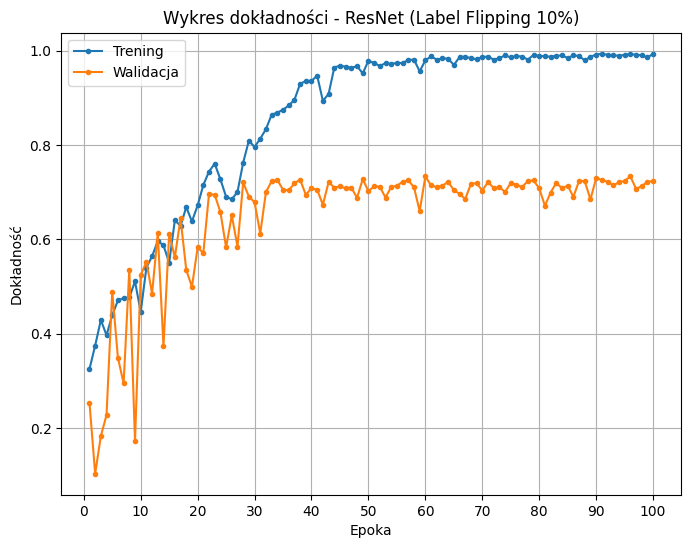

In [ ]:
## Wykres dokładności (Resnet 10%)
epochs_num_10 = range(1, len(training_accuracy_10) + 1)
plt.figure(figsize=(8, 6))
plt.plot(epochs_num_10, training_accuracy_10, label='Trening', marker='.')
plt.plot(epochs_num_10, validation_accuracy_10, label='Walidacja', marker='.')

plt.title('Wykres dokładności - ResNet (Label Flipping 10%)')
plt.xlabel('Epoka')
plt.ylabel('Dokładność')

plt.xticks(range(0, len(training_accuracy_10) + 1, 10) )
plt.legend()
plt.grid(True)

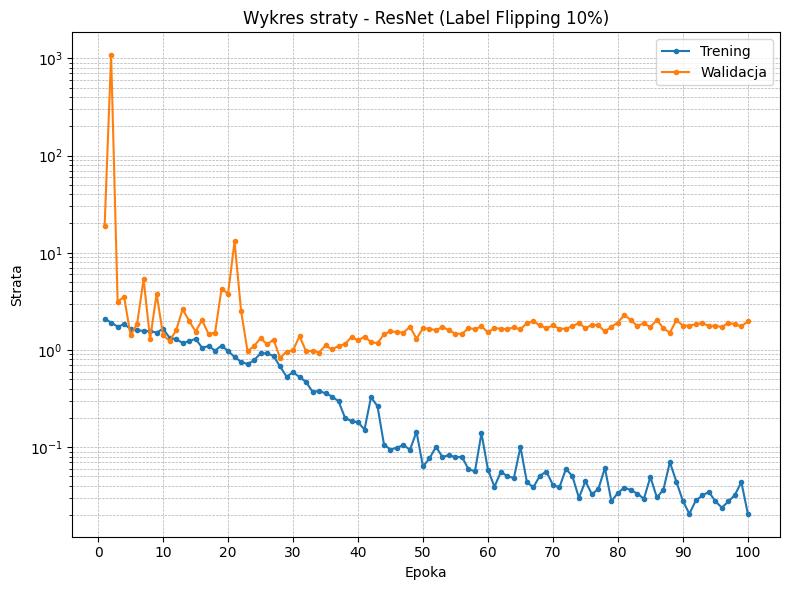

In [ ]:
# Tu logarytmiczna - jedna do wywalenia zależy
plt.figure(figsize=(8, 6))
plt.plot(epochs_num_10, training_loss_10, label='Trening', marker='.')
plt.plot(epochs_num_10, validation_loss_10, label='Walidacja', marker='.')

plt.title('Wykres straty - ResNet (Label Flipping 10%)')
plt.xlabel('Epoka')
plt.ylabel('Strata')

plt.yscale('log')
plt.xticks(range(0, int(max(epochs_num_10)) + 1, 10))

plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step

--- RAPORT SZCZEGÓŁOWY - ResNet (Label Flipping 10%) ---
              precision    recall  f1-score   support

     Samolot       0.76      0.81      0.79      1000
    Samochód       0.81      0.73      0.77      1000
        Ptak       0.73      0.56      0.64      1000
         Kot       0.57      0.46      0.51      1000
       Jeleń       0.64      0.76      0.69      1000
        Pies       0.68      0.54      0.60      1000
        Żaba       0.71      0.89      0.79      1000
         Koń       0.77      0.82      0.79      1000
      Statek       0.82      0.87      0.85      1000
  Ciężarówka       0.71      0.78      0.75      1000

    accuracy                           0.72     10000
   macro avg       0.72      0.72      0.72     10000
weighted avg       0.72      0.72      0.72     10000



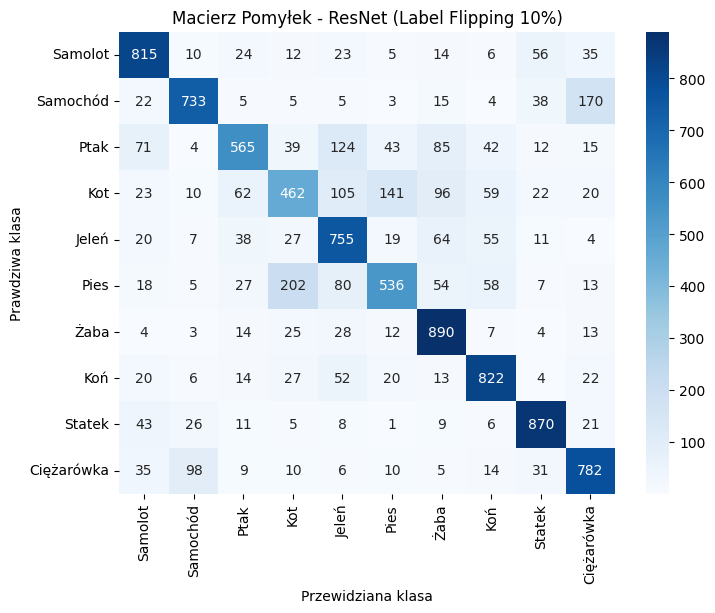

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

print("\n--- RAPORT SZCZEGÓŁOWY - ResNet (Label Flipping 10%) ---")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Macierz Pomyłek - ResNet (Label Flipping 10%)')
plt.ylabel('Prawdziwa klasa')
plt.xlabel('Przewidziana klasa')
plt.show()

## 20%

In [ ]:
## Tworzenie naszego modelu ResNet
import numpy as np
y_train_poisoned_20 = poison_label(y_train_cat, ratio=0.2)
model = resnet_model()
model.summary()
start_time = time.time()
resnet_20 = model.fit(
    x_train, y_train_poisoned_20,
    epochs=100,
    batch_size=64,
    validation_data=(x_test, y_test_cat),
    verbose=1
)
end_time = time.time()
duration = end_time - start_time
print(f"Czas = {duration}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 38, 38, 3) │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 16, 16,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 16, 16,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 16, 16,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 18, 18,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 8, 8, 64)  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 8, 64)  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 8, 64)  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 8, 8, 256) │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_3_c

 Total params: 23,608,202 (90.06 MB)

 Trainable params: 23,555,082 (89.86 MB)

 Non-trainable params: 53,120 (207.50 KB)

Epoch 1/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 109s 70ms/step - accuracy: 0.3436 - loss: 1.9824 - val_accuracy: 0.1000 - val_loss: 1734.6208
Epoch 2/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.3307 - loss: 1.9848 - val_accuracy: 0.1160 - val_loss: 212.9321
Epoch 3/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.3577 - loss: 1.9315 - val_accuracy: 0.3651 - val_loss: 2.0810
Epoch 4/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 36ms/step - accuracy: 0.3305 - loss: 1.9876 - val_accuracy: 0.2423 - val_loss: 2.1330
Epoch 5/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 36ms/step - accuracy: 0.3606 - loss: 1.8791 - val_accuracy: 0.3227 - val_loss: 2.3097
Epoch 6/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 36ms/step - accuracy: 0.4051 - loss: 1.7447 - val_accuracy: 0.2161 - val_loss: 2.6379
Epoch 7/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 36ms/step - accuracy: 0.3466 - loss: 1.9152 - val_accuracy: 0.4214 - val_loss: 2.2439
Epoch 8/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 36ms/step - accuracy: 0.3934 - l

In [ ]:
results_20 = model.evaluate(x_test, y_test_cat, verbose=0)
global_loss_20 = results_20[0]
global_acc_20 = results_20[1]
print(global_acc_20)
print(global_loss_20)

0.6929000020027161
1.7333765029907227


In [ ]:
## Wyciągnięcie parametrów potrzebnych do naszych wykresów (ResNet 20%)
training_accuracy_20 = resnet_20.history['accuracy']
training_loss_20 = resnet_20.history['loss']
validation_accuracy_20 = resnet_20.history['val_accuracy']
validation_loss_20 = resnet_20.history['val_loss']

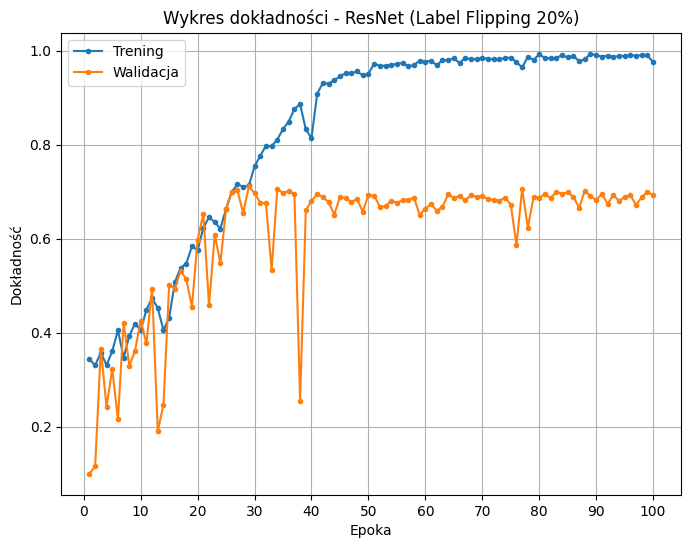

In [ ]:
## Wykres dokładności (Resnet 20%)
epochs_num_20 = range(1, len(training_accuracy_20) + 1)
plt.figure(figsize=(8, 6))
plt.plot(epochs_num_20, training_accuracy_20, label='Trening', marker='.')
plt.plot(epochs_num_20, validation_accuracy_20, label='Walidacja', marker='.')

plt.title('Wykres dokładności - ResNet (Label Flipping 20%)')
plt.xlabel('Epoka')
plt.ylabel('Dokładność')

plt.xticks(range(0, len(training_accuracy_20) + 1, 10) )
plt.legend()
plt.grid(True)

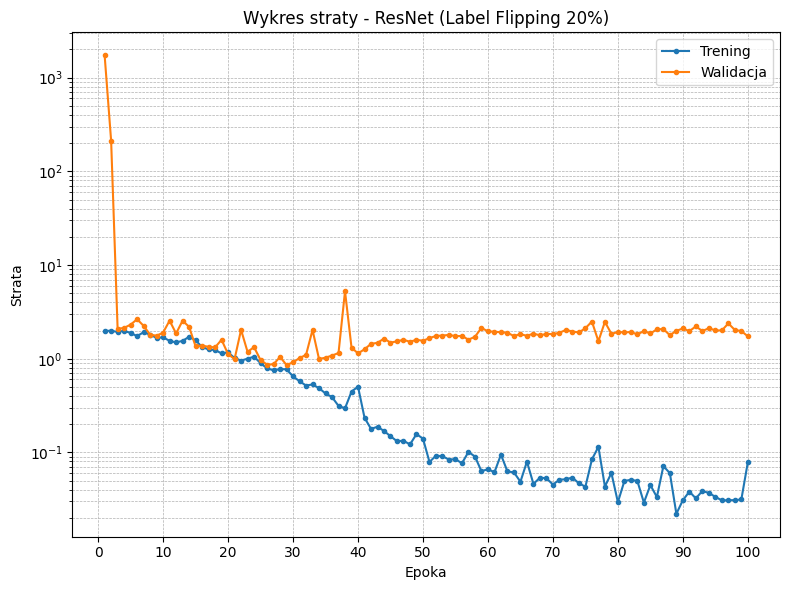

In [ ]:
# Wykres straty (Resnet LF 20%)
plt.figure(figsize=(8, 6))
plt.plot(epochs_num_20, training_loss_20, label='Trening', marker='.')
plt.plot(epochs_num_20, validation_loss_20, label='Walidacja', marker='.')

plt.title('Wykres straty - ResNet (Label Flipping 20%)')
plt.xlabel('Epoka')
plt.ylabel('Strata')

plt.yscale('log')
plt.xticks(range(0, int(max(epochs_num_20)) + 1, 10))

plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step

--- RAPORT SZCZEGÓŁOWY - ResNet (Label Flipping 20%) ---
              precision    recall  f1-score   support

     Samolot       0.73      0.81      0.77      1000
    Samochód       0.74      0.72      0.73      1000
        Ptak       0.66      0.64      0.65      1000
         Kot       0.48      0.47      0.48      1000
       Jeleń       0.69      0.69      0.69      1000
        Pies       0.52      0.54      0.53      1000
        Żaba       0.80      0.76      0.78      1000
         Koń       0.77      0.80      0.78      1000
      Statek       0.86      0.80      0.82      1000
  Ciężarówka       0.70      0.70      0.70      1000

    accuracy                           0.69     10000
   macro avg       0.69      0.69      0.69     10000
weighted avg       0.69      0.69      0.69     10000



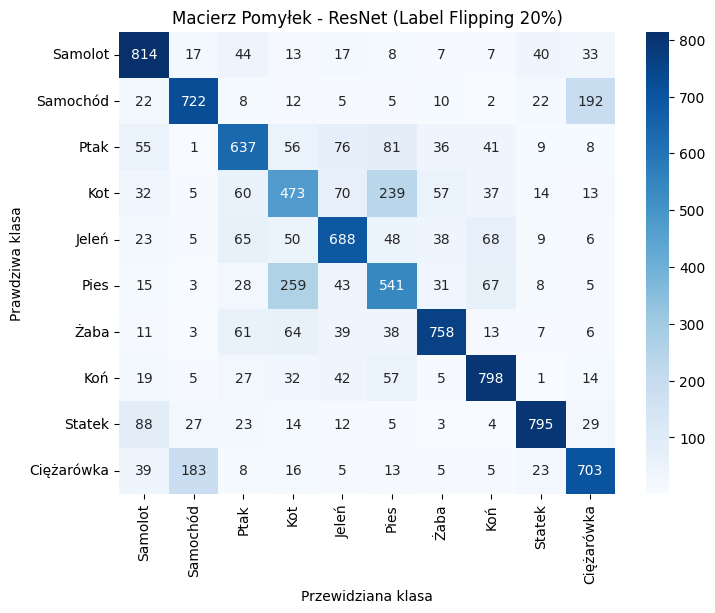

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

print("\n--- RAPORT SZCZEGÓŁOWY - ResNet (Label Flipping 20%) ---")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Macierz Pomyłek - ResNet (Label Flipping 20%)')
plt.ylabel('Prawdziwa klasa')
plt.xlabel('Przewidziana klasa')
plt.show()

## 30%

In [ ]:
## Tworzenie naszego modelu ResNet
import numpy as np
y_train_poisoned_30 = poison_label(y_train_cat, ratio=0.3)
model = resnet_model()
model.summary()
start_time = time.time()
resnet_30 = model.fit(
    x_train, y_train_poisoned_30,
    epochs=100,
    batch_size=64,
    validation_data=(x_test, y_test_cat),
    verbose=1
)
end_time = time.time()
duration = end_time - start_time
print(f"Czas = {duration}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 38, 38, 3) │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 16, 16,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 16, 16,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 16, 16,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 18, 18,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 8, 8, 64)  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 8, 64)  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 8, 64)  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 8, 8, 256) │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_3_c

 Total params: 23,608,202 (90.06 MB)

 Trainable params: 23,555,082 (89.86 MB)

 Non-trainable params: 53,120 (207.50 KB)

Epoch 1/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 110s 71ms/step - accuracy: 0.3477 - loss: 1.9676 - val_accuracy: 0.4157 - val_loss: 1.6542
Epoch 2/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 36ms/step - accuracy: 0.3830 - loss: 1.8407 - val_accuracy: 0.2367 - val_loss: 2.5922
Epoch 3/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.4075 - loss: 1.7160 - val_accuracy: 0.3304 - val_loss: 2.5018
Epoch 4/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - accuracy: 0.4320 - loss: 1.7038 - val_accuracy: 0.2257 - val_loss: 13.2584
Epoch 5/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.3775 - loss: 1.8072 - val_accuracy: 0.1864 - val_loss: 23.4744
Epoch 6/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.4192 - loss: 1.6542 - val_accuracy: 0.3340 - val_loss: 1.9194
Epoch 7/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.4589 - loss: 1.5100 - val_accuracy: 0.4330 - val_loss: 2.5844
Epoch 8/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 36ms/step - accuracy: 0.5034 - loss

In [ ]:
results_30 = model.evaluate(x_test, y_test_cat, verbose=0)
global_loss_30 = results_30[0]
global_acc_30 = results_30[1]
print(global_acc_30)
print(global_loss_30)

0.6855999827384949
1.9778958559036255


In [ ]:
## Wyciągnięcie parametrów potrzebnych do naszych wykresów (ResNet 30%)
training_accuracy_30 = resnet_30.history['accuracy']
training_loss_30 = resnet_30.history['loss']
validation_accuracy_30 = resnet_30.history['val_accuracy']
validation_loss_30 = resnet_30.history['val_loss']

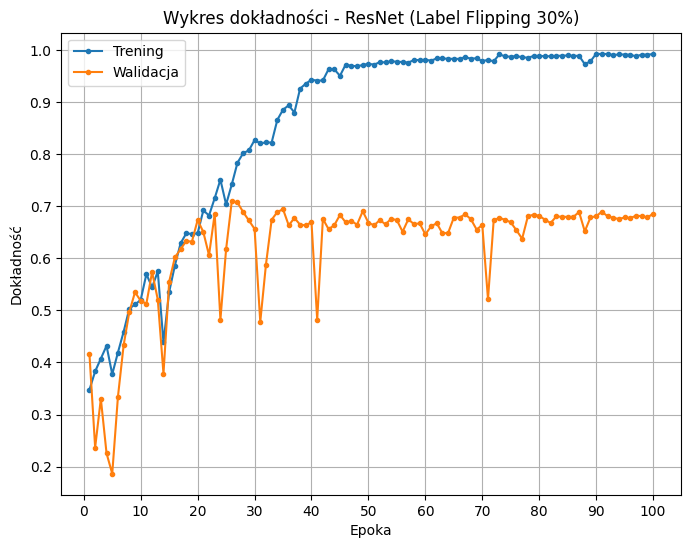

In [ ]:
## Wykres dokładności (Resnet 20%)
epochs_num_30 = range(1, len(training_accuracy_30) + 1)
plt.figure(figsize=(8, 6))
plt.plot(epochs_num_30, training_accuracy_30, label='Trening', marker='.')
plt.plot(epochs_num_30, validation_accuracy_30, label='Walidacja', marker='.')

plt.title('Wykres dokładności - ResNet (Label Flipping 30%)')
plt.xlabel('Epoka')
plt.ylabel('Dokładność')

plt.xticks(range(0, len(training_accuracy_30) + 1, 10) )
plt.legend()
plt.grid(True)

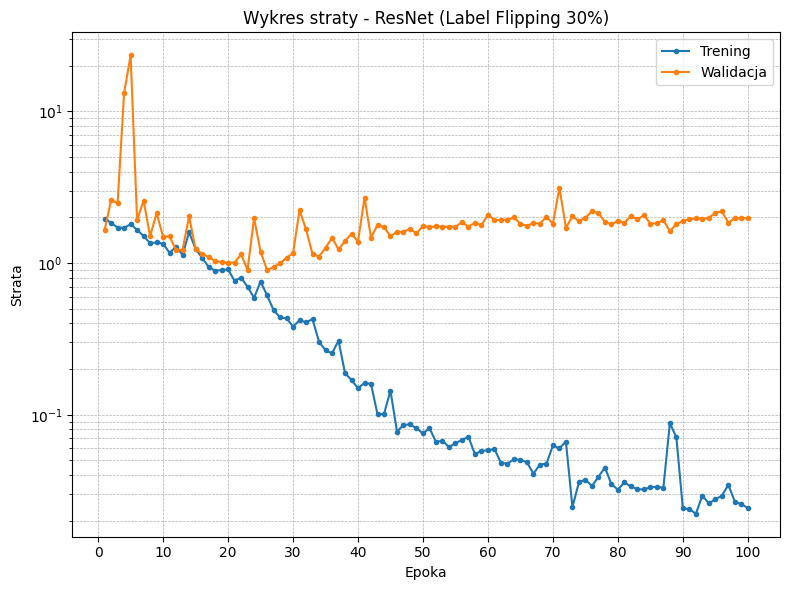

In [ ]:
# Wykres straty (Resnet LF 30%)
plt.figure(figsize=(8, 6))
plt.plot(epochs_num_30, training_loss_30, label='Trening', marker='.')
plt.plot(epochs_num_30, validation_loss_30, label='Walidacja', marker='.')

plt.title('Wykres straty - ResNet (Label Flipping 30%)')
plt.xlabel('Epoka')
plt.ylabel('Strata')

plt.yscale('log')
plt.xticks(range(0, int(max(epochs_num_30)) + 1, 10))

plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step

--- RAPORT SZCZEGÓŁOWY - ResNet (Label Flipping 30%) ---
              precision    recall  f1-score   support

     Samolot       0.75      0.80      0.78      1000
    Samochód       0.70      0.62      0.66      1000
        Ptak       0.63      0.72      0.67      1000
         Kot       0.44      0.42      0.43      1000
       Jeleń       0.68      0.76      0.71      1000
        Pies       0.51      0.46      0.48      1000
        Żaba       0.83      0.79      0.81      1000
         Koń       0.79      0.79      0.79      1000
      Statek       0.84      0.86      0.85      1000
  Ciężarówka       0.67      0.65      0.66      1000

    accuracy                           0.69     10000
   macro avg       0.68      0.69      0.68     10000
weighted avg       0.68      0.69      0.68     10000



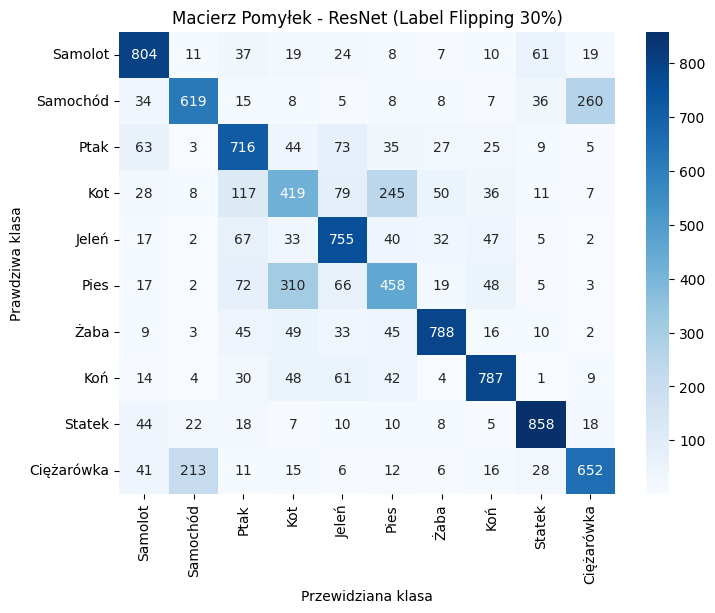

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

print("\n--- RAPORT SZCZEGÓŁOWY - ResNet (Label Flipping 30%) ---")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Macierz Pomyłek - ResNet (Label Flipping 30%)')
plt.ylabel('Prawdziwa klasa')
plt.xlabel('Przewidziana klasa')
plt.show()